In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import MinMaxScaler

2026-02-05 16:07:51.101763: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770336471.131371 1501844 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770336471.137868 1501844 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770336471.157397 1501844 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770336471.157418 1501844 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770336471.157420 1501844 computation_placer.cc:177] computation placer alr

In [2]:
def D_JS(p1,p2,tol=1e-16):
    p1=p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [5]:
# Fully working 

################# CAE_full_3D #############
from keras.models import load_model
import keras

import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class RenormalizeToEight(tf.keras.layers.Layer):
    def call(self, x):
        total = tf.reduce_sum(x, axis=[1, 2, 3, 4], keepdims=True)
        return x / (total + 1e-8) * 8.0


@tf.keras.utils.register_keras_serializable()
def jensen_shannon_divergence_loss(y_true, y_pred):
    y_t = tf.cast(y_true, tf.float32)
    y_p = tf.cast(y_pred, tf.float32)

    y_t = tf.reshape(y_t, [tf.shape(y_t)[0], -1])
    y_p = tf.reshape(y_p, [tf.shape(y_p)[0], -1])

    y_t /= tf.reduce_sum(y_t, axis=1, keepdims=True) + 1e-8
    y_p /= tf.reduce_sum(y_p, axis=1, keepdims=True) + 1e-8

    m = 0.5 * (y_t + y_p)
    kl_true = tf.reduce_sum(y_t * tf.math.log((y_t + 1e-8) / (m + 1e-8)), axis=1)
    kl_pred = tf.reduce_sum(y_p * tf.math.log((y_p + 1e-8) / (m + 1e-8)), axis=1)
    return tf.reduce_mean(0.5 * (kl_true + kl_pred))
    
from keras.models import load_model
import keras
keras.config.enable_unsafe_deserialization()


def CAE_3D_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = test_d
    ref_rgb  = ref_d
    reshaped_arr = test_rgb.reshape(1,64, 64, 64, 1)
    
    denoised_rgb = CAE_3D_mod.predict(reshaped_arr)  # shape: (H, W, 3)
    



    # Reconstruct full 3D volume
    denoised_d = denoised_rgb.reshape(64,64,64)

    # --- Evaluation ---
    print("\n>>> Evaluation Metrics")
    jsd_noisy = jensen_shannon_divergence_loss(test_d,
        ref_d
    )
    jsd_denoised = jensen_shannon_divergence_loss(
        denoised_d,
        ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")

    print(test_d.shape,denoised_d.shape,ref_d.shape)

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised)


In [6]:
print("IMG 3D loaded")

IMG 3D loaded


In [8]:
print(model_files)

['/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_3D_Models/2336000000CAE_3D.keras', '/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_3D_Models/2385000CAE_3D.keras', '/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_3D_Models/238800000000CAE_3D.keras', '/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_3D_Models/23930000CAE_3D.keras', '/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_3D_Models/240700000CAE_3D.keras', '/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_3D_Models/24080000000CAE_3D.keras']


Found 1 noisy files.
Found 1 CAE_3D models.

=== Running model: 24080000000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000025
JSD   (denoised vs ref):  0.000159
(64, 64, 64) (64, 64, 64) (64, 64, 64)


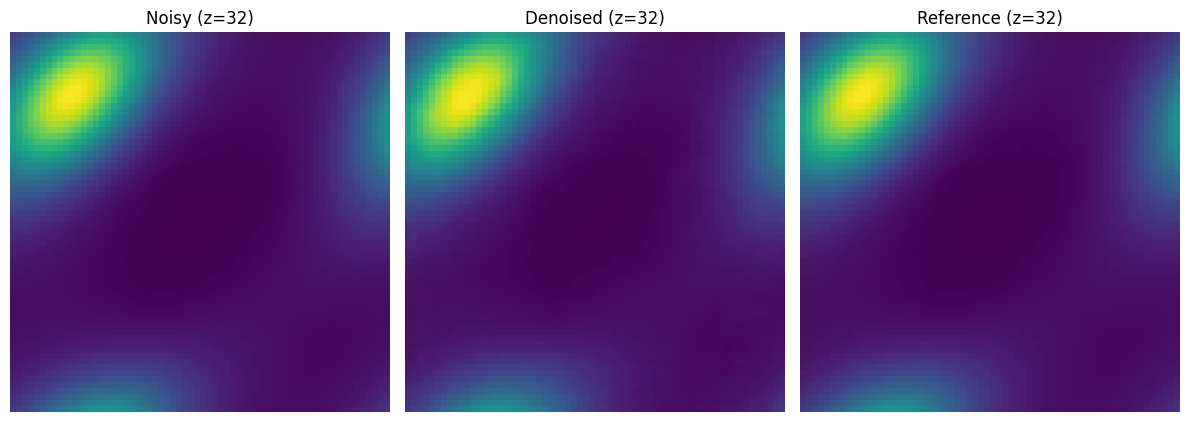

Results saved to 24080000000CAE_3D__3D_results.csv


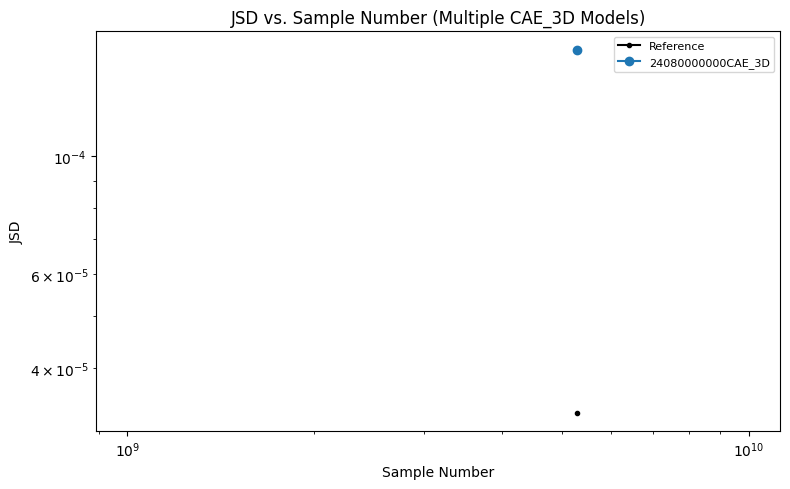

In [9]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import h5py
import csv

# Enable unsafe deserialization for custom keras objects
keras = tf.keras
keras.config.enable_unsafe_deserialization()


CAE_3D_mod = None

# ==== Paths ====
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
noisy_files = [ '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_5283219951.h5']


# Directory containing *_CAE_3D.keras models
model_dir = "/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_3D_Models"
model_files = ['/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_3D_Models/24080000000CAE_3D.keras']

print(f"Found {len(noisy_files)} noisy files.")
print(f"Found {len(model_files)} CAE_3D models.")

# ==== Reference JSD ====
results_ref = []
with h5py.File(ref_path, 'r') as file:
    ref_d_full = file['density'][:]

for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    jsd = D_JS(ref_d_full, test_d)
    results_ref.append((sample_num, jsd))

results_array_ref = np.array(sorted(results_ref, key=lambda x: x[0]))

# ==== Process each CAE_3D model ====
all_results = {}

for model_path in model_files:
    model_name = os.path.basename(model_path).replace(".keras", "")
    print(f"\n=== Running model: {model_name} ===")

    CAE_3D_mod = keras.models.load_model(
        model_path,
        custom_objects={
            "RenormalizeToEight": RenormalizeToEight,
            "jensen_shannon_divergence_loss": jensen_shannon_divergence_loss
        }
    )

    model_results = []
    for noisy_path in noisy_files:
        match = re.search(r"(\d+)\.h5$", noisy_path)
        if not match:
            continue
        sample_num = int(match.group(1))

        with h5py.File(noisy_path, 'r') as file:
            test_d = file['density'][:]

        # Call your existing function
        _, jsd_denoised = CAE_3D_test_pipeline(test_d, ref_d_full)
        model_results.append((sample_num, jsd_denoised))

    all_results[model_name] = np.array(sorted(model_results, key=lambda x: x[0]))
# Save to CSV
filename = f'{model_name}__3D_results.csv'
header = ['sample_num', 'jsd_denoised']

with open(filename, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(model_results)

print(f"Results saved to {filename}")

# ==== Plot ====
plt.figure(figsize=(8, 5))

# Reference line
plt.loglog(results_array_ref[:, 0], results_array_ref[:, 1],
           marker=".", linestyle="-", color="black", label="Reference")

# Model lines
colors = plt.cm.tab20(np.linspace(0, 1, len(all_results)))
for color, (name, data) in zip(colors, all_results.items()):
    plt.loglog(data[:, 0], data[:, 1],
               marker="o", linestyle="-", label=name, color=color)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.title("JSD vs. Sample Number (Multiple CAE_3D Models)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
